# Lab 4: Population Coding - Data

#### Stephen Spivack, CDS Adjunct, Fall 2025

Import libraries

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery
from scipy.optimize import curve_fit

/Users/sspivack/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Initialize client

In [2]:
%load_ext google.cloud.bigquery
client = bigquery.Client() 

Ingest data

In [3]:
%%bigquery motor_cortex
  select *
  from neural-ds-fe73.lab4_population_coding.motor_cortex

Query is running:   0%|          |

Downloading:   0%|          |

In [4]:
motor_cortex
#143 neurons, #158 trials

,trial_id,cell_id,brain_area,window,spike_count,direction,instruction_time,go_time
0,0,0,PMd,instruction,0.0,3,14.852567,16.308333
1,0,0,PMd,go,8.0,3,14.852567,16.308333
2,0,1,PMd,instruction,9.0,3,14.852567,16.308333
3,0,1,PMd,go,23.0,3,14.852567,16.308333
4,0,2,PMd,instruction,3.0,3,14.852567,16.308333
...,...,...,...,...,...,...,...,...
45183,157,140,MI,go,16.0,8,1310.062867,1311.268667
45184,157,141,MI,instruction,0.0,8,1310.062867,1311.268667
45185,157,141,MI,go,2.0,8,1310.062867,1311.268667
45186,157,142,MI,instruction,4.0,8,1310.062867,1311.268667


### Neural Encoding and Decoding

#### Encoding
- Neural activity (spike rate) is modeled as a function of behavior.
- Example: firing rate varies with movement direction.

#### Decoding
- Behavior is inferred from neural activity.
- Goal: **predict upcoming arm movement direction** from a *population* of motor cortex neurons.

---

### Why Population Coding?

**Limitations of single-neuron encoding:**
1. **Symmetric tuning**: Cosine-like curves → same rate for two opposite directions.
2. **Noise**: Single neurons are unreliable.

**Solution**: Combine responses across neurons — population-level decoding averages out ambiguity and noise.

---

### Population Vector Algorithm (Georgopoulos et al., 1986)

Each neuron's contribution is a vector in its preferred direction, scaled by how much its firing increases from baseline:

$$
\mathbf{P}(M) = \sum_{i=1}^{N} w_i(M) \cdot \mathbf{C}_i
$$

Where:
- $\mathbf{P}(M)$: predicted movement direction (population vector)
- $N$: number of neurons
- $\mathbf{C}_i$: unit vector in preferred direction of neuron $i$
- $w_i(M)$: activity weight = $d_i(M) - b_i$
- $d_i(M)$: firing rate during movement $M$
- $b_i$: baseline firing rate

**Simplified form:**

$$
\mathbf{P}(M) = \sum_{i=1}^{N} \left(d_i(M) - b_i\right) \cdot \mathbf{C}_i
$$


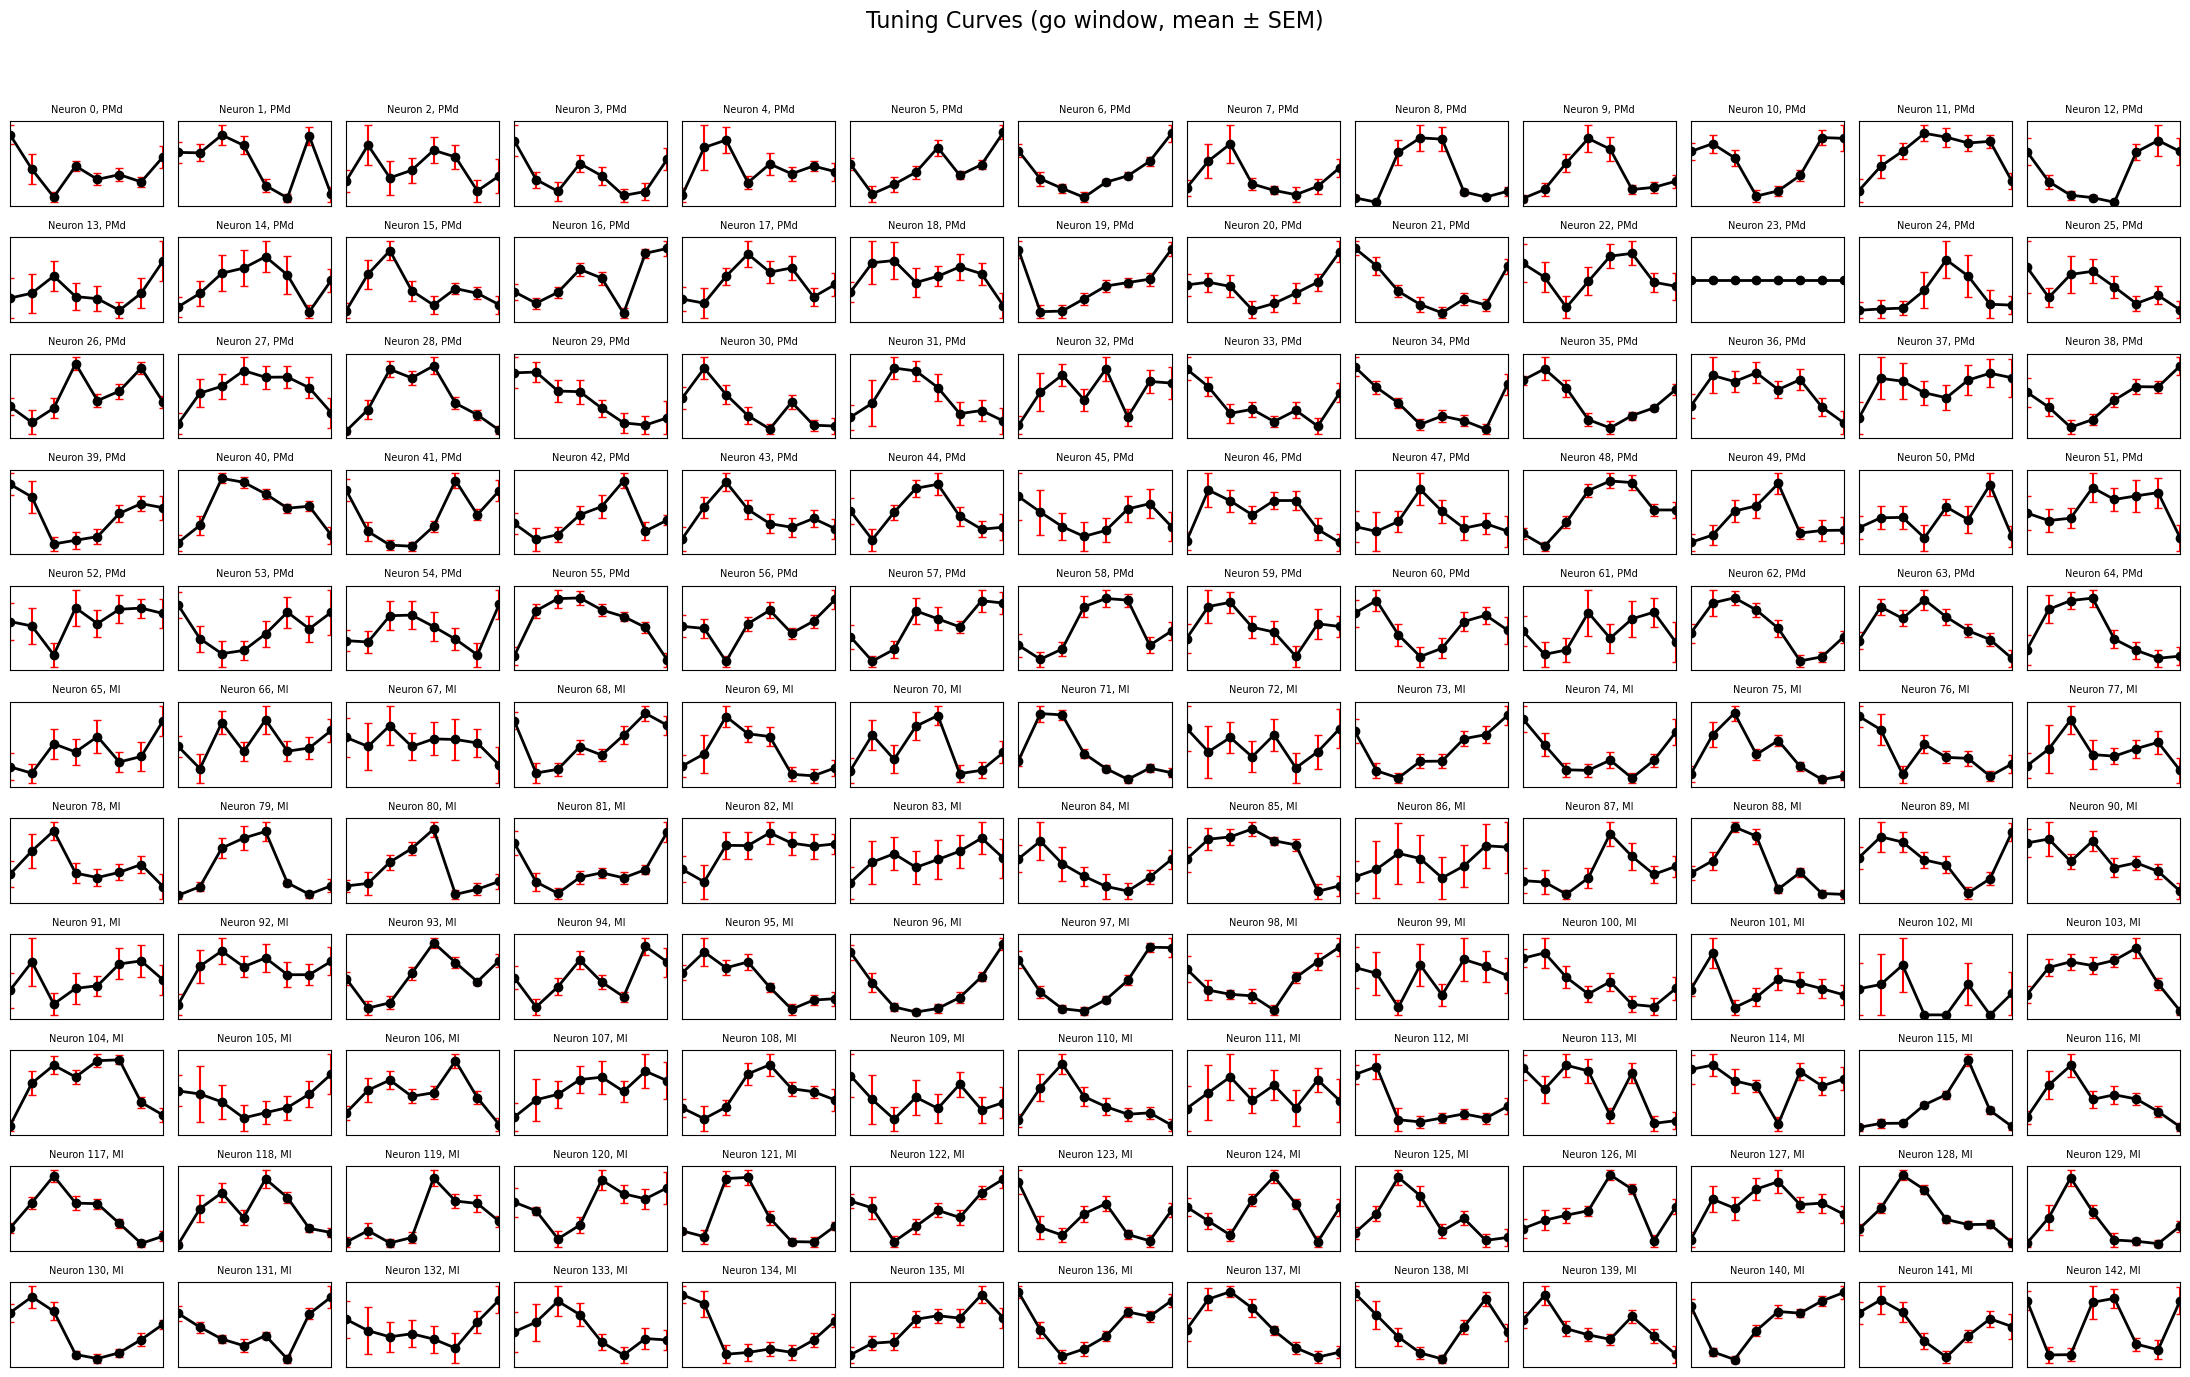

In [5]:
# =========================================================
# Step 1: Select a time window (instruction or go cue aligned)
# =========================================================
window = "go" # or instruction
motor_cortex_window = motor_cortex[motor_cortex["window"] == window]

# =========================================================
# Step 2: Group data by (cell_id, direction) and compute:
#         - mean spike count
#         - standard deviation
#         - SEM (standard error of the mean)
# =========================================================
grouped = motor_cortex_window.groupby(["cell_id", "direction"])
summary = grouped.agg(
    mean_spike=("spike_count", "mean"),
    std_spike=("spike_count", "std"),
    n=("spike_count", "count")
).reset_index()
summary["sem_spike"] = summary["std_spike"] / np.sqrt(summary["n"])

# =========================================================
# Step 3: Prepare axes and metadata
#         - directions = movement angles (e.g. 0°–360°)
#         - cell_ids   = neuron indices (0 to 142)
#         - brain area = PMd or MT
# =========================================================
directions = np.sort(motor_cortex["direction"].unique())
cell_ids = np.sort(motor_cortex["cell_id"].unique())
cell_area_map = motor_cortex.drop_duplicates("cell_id").set_index("cell_id")["brain_area"].to_dict()

# =========================================================
# Step 4: Plot each neuron’s tuning curve
#         - x-axis = direction
#         - y-axis = spike count (mean ± SEM)
#         - black lines, red error bars
# =========================================================
fig, axes = plt.subplots(11, 13, figsize=(22, 14))
axes = axes.flatten()

for i, cell_id in enumerate(cell_ids):
    ax = axes[i]
    cell_data = summary[summary["cell_id"] == cell_id]

    # Align direction values
    means = [cell_data[cell_data["direction"] == d]["mean_spike"].values[0] if d in cell_data["direction"].values else np.nan for d in directions]
    errors = [cell_data[cell_data["direction"] == d]["sem_spike"].values[0] if d in cell_data["direction"].values else np.nan for d in directions]

    # Plot tuning curve
    ax.errorbar(
        directions, means, yerr=errors,
        fmt='-o', linewidth=2, color='black',
        ecolor='red', elinewidth=1.5, capsize=3
    )
    brain_area = cell_area_map.get(cell_id, "Unknown")
    ax.set_title(f"Neuron {cell_id}, {brain_area}", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(directions.min(), directions.max())

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Title and layout
fig.suptitle(f"Tuning Curves ({window} window, mean ± SEM)", fontsize=16)
fig.patch.set_facecolor("white")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
